## CLIP 모델 스크래치(패션 MNIST 데이터)

하이퍼파라메터 설정

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from PIL import Image

import timm
from transformers import DistilBertTokenizer, DistilBertModel
import numpy as np
from tqdm import tqdm

# 1. 설정 및 하이퍼파라미터
IMAGE_MODEL_NAME = 'resnet18'
TEXT_MODEL_NAME = 'distilbert-base-uncased'
IMAGE_EMBEDDING_DIM = 512   # resnet18의 출력 차원
TEXT_EMBEDDING_DIM = 768    # distilbert의 출력 차원
PROJECTION_DIM = 256        # 최종 임베딩 차원

# 학습 관련 설정
BATCH_SIZE = 64  # 128 -> 64로 감소 (더 안정적인 대조 학습)
NUM_EPOCHS = 3
LEARNING_RATE = 3e-4  # 1e-4 -> 3e-4로 증가 (더 빠른 수렴)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
VAL_SPLIT = 0.2  # Validation 데이터 비율

# 텍스트 토큰화 관련 설정
MAX_LENGTH = 32

print(f"Using device: {DEVICE}")


Using device: cuda


Fashion-MNIST 데이터셋 준비

In [44]:
class FashionMNISTDataset(Dataset):
	"""Fashion-MNIST 데이터셋을 CLIP 학습에 맞게 변환하는 클래스."""
	def __init__(self, train=True, transform=None):
		# torchvision을 통해 Fashion-MNIST 데이터셋을 로드.
		self.dataset = FashionMNIST(root="./data", train=train, download=True)
		self.transform = transform
		self.tokenizer = DistilBertTokenizer.from_pretrained(TEXT_MODEL_NAME)

		# 숫자 레이블을 실제 클래스 이름으로 매핑.
		self.class_names = [
			"T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
			"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
		]

	def __len__(self):
		return len(self.dataset)

	def __getitem__(self, idx):
		image, label_idx = self.dataset[idx] # 이미지와 숫자 레이블을 가져옴.
		if self.transform:
			image = self.transform(image) # 이미지 변환 적용

		caption = f"a photo of a {self.class_names[label_idx]}" # 숫자 레이블을 이용해 동적으로 캡션을 생성. 실제로는 더 다양한 캡션, 설명을 학습 데이터로 사용할 수 있음. 간단한 예시를 위해 이렇게 작성.
		encoded_caption = self.tokenizer(
			caption, padding='max_length', truncation=True, max_length=MAX_LENGTH, return_tensors='pt'
		) # 캡션을 토큰화.

		return {
			'image': image,
			'input_ids': encoded_caption['input_ids'].squeeze(0),
			'attention_mask': encoded_caption['attention_mask'].squeeze(0),
			'label': label_idx  # 평가 시 사용할 레이블
		} # 최종 데이터를 딕셔너리 형태로 반환.

def get_transforms():
	"""이미지 전처리 파이프라인을 정의."""
	return transforms.Compose([
		transforms.Resize((224, 224)),
		transforms.Grayscale(num_output_channels=3), # 흑백 -> 3채널 RGB로 변환
		transforms.ToTensor(),
		transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
	])



모델 아키텍처 구현

In [45]:
class ImageEncoder(nn.Module):
	"""이미지 인코더: ResNet18"""
	def __init__(self, pretrained=True, trainable=True):
		super().__init__()
		self.model = timm.create_model(IMAGE_MODEL_NAME, pretrained, num_classes=0, global_pool='avg')
		for p in self.model.parameters():
			p.requires_grad = trainable

	def forward(self, x):
		return self.model(x)

class TextEncoder(nn.Module):
	"""텍스트 인코더: DistilBERT"""
	def __init__(self, pretrained=True, trainable=True):
		super().__init__()
		self.model = DistilBertModel.from_pretrained(TEXT_MODEL_NAME)
		for p in self.model.parameters():
			p.requires_grad = trainable

	def forward(self, input_ids, attention_mask):
		output = self.model(input_ids=input_ids, attention_mask=attention_mask)
		return output.last_hidden_state[:, 0, :] # 문장 전체를 요약해 대표하는 [CLS] 토큰(0번째 토큰)의 임베딩을 사용합니다.

class ProjectionHead(nn.Module):
	"""이미지와 텍스트 임베딩을 동일한 차원으로 투영하는 MLP. 서로 다른 모달리티를 같은 공간에 매핑"""
	def __init__(self, embedding_dim, projection_dim, dropout=0.1):
		super().__init__()
		self.projection = nn.Linear(embedding_dim, projection_dim)
		self.gelu = nn.GELU() # GELU: 부드러운 비선형성 추가 (음수값도 일부 통과)
		self.fc = nn.Linear(projection_dim, projection_dim) # 복잡한 패턴 학습
		self.dropout = nn.Dropout(dropout) # 학습 시 뉴런 무작위 제거 (일반화 성능 향상)
		self.layer_norm = nn.LayerNorm(projection_dim)

	def forward(self, x):
		projected = self.projection(x)
		x = self.gelu(projected)
		x = self.fc(x)
		x = self.dropout(x)
		x = x + projected # 기울기 소실 방지: 깊은 네트워크에서도 역전파가 원활
		x = self.layer_norm(x)
		return x


CLIP 모델 정의

In [46]:
class CLIPModel(nn.Module):
	def __init__(self):
		super().__init__()
		self.image_encoder = ImageEncoder()
		self.text_encoder = TextEncoder()
		self.image_projection = ProjectionHead(embedding_dim=IMAGE_EMBEDDING_DIM, projection_dim=PROJECTION_DIM)
		self.text_projection = ProjectionHead(embedding_dim=TEXT_EMBEDDING_DIM, projection_dim=PROJECTION_DIM)
		self.temperature = nn.Parameter(torch.tensor(0.07))  # CLIP 논문 권장값

	def forward(self, batch):
		# 각 인코더와 프로젝션 헤드를 통과시켜 임베딩을 얻음.
		# 학습 시 사용되면 안되는 토큰은 마스킹해서 알려줌.
		image_features = self.image_encoder(batch['image'])
		# attention_mask는 실제 토큰(패딩이 아닌 부분)만 인코더가 처리하도록 알려줌.
		text_features = self.text_encoder(batch['input_ids'], batch['attention_mask'])

		image_embeddings = self.image_projection(image_features)
		text_embeddings = self.text_projection(text_features)

		# L2 정규화. 임베딩 벡터의 크기를 1로 맞춰줌. 수식은 벡터를 자신의 L2 노름(크기)으로 나누는 것과 같음.
		image_embeddings = F.normalize(image_embeddings, p=2, dim=-1)
		text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)

		return image_embeddings, text_embeddings



손실함수 정의. 로짓(Logits) 및 유사도 계산

<div style="font-size: 80%;">

$$ \text{logits}_{i,j} = \frac{\mathbf{t}_i \cdot \mathbf{i}_j^\top}{\tau} $$

대칭적 손실 함수 (Symmetric Loss)
$$ \mathcal{L} = \frac{1}{2} \left( \mathcal{L}_{\text{image} \to \text{text}} + \mathcal{L}_{\text{text} \to \text{image}} \right) $$

세부 Cross Entropy 계산
$$ \mathcal{L}_{\text{image} \to \text{text}} = -\frac{1}{N} \sum_{i=1}^N \log \frac{\exp(\text{logits}_{i,i})}{\sum_{j=1}^N \exp(\text{logits}_{j,i})} $$
$$ \mathcal{L}_{\text{text} \to \text{image}} = -\frac{1}{N} \sum_{i=1}^N \log \frac{\exp(\text{logits}_{i,i})}{\sum_{j=1}^N \exp(\text{logits}_{i,j})} $$

여기서 각 기호의 의미는 다음과 같음.
* $\mathbf{i}, \mathbf{t}$: 이미지 및 텍스트 임베딩 벡터
* $\tau$: 온도 파라미터 (`temperature`, 결과값을 부드럽게 혹은 날카롭게 조절)
* $N$: 배구 크기 (Batch Size)

계산된 유사도 행렬 예시.
$$
\text{Logits} =
\begin{bmatrix}
\mathbf{T}_0 \cdot \mathbf{I}_0 & \mathbf{T}_0 \cdot \mathbf{I}_1 & \cdots & \mathbf{T}_0 \cdot \mathbf{I}_{N-1} \\
\mathbf{T}_1 \cdot \mathbf{I}_0 & \mathbf{T}_1 \cdot \mathbf{I}_1 & \cdots & \mathbf{T}_1 \cdot \mathbf{I}_{N-1} \\
\vdots & \vdots & \ddots & \vdots \\
\mathbf{T}_{N-1} \cdot \mathbf{I}_0 & \mathbf{T}_{N-1} \cdot \mathbf{I}_1 & \cdots & \mathbf{T}_{N-1} \cdot \mathbf{I}_{N-1}
\end{bmatrix}
$$

* **Rows ($T_i$):** 개별 텍스트(Text) 샘플
* **Columns ($I_j$):** 개별 이미지(Image) 샘플

In [ ]:
def contrastive_loss(image_embeddings, text_embeddings, temperature):
	logits = (text_embeddings @ image_embeddings.T) / temperature   # cosine 유사도 계산값을 온도값으로 나눠 스케일링 처리
	labels = torch.arange(image_embeddings.shape[0], device=DEVICE)
	loss_i = F.cross_entropy(logits.T, labels)
	loss_t = F.cross_entropy(logits, labels)
	return (loss_i + loss_t) / 2.0 # 이미지->텍스트, 텍스트->이미지 방향 모두 고려한 대칭적 손실


학습/추론 함수 정의

CLIP Similarity Logits Formula

<div style="font-size: 90%;">

$$
\text{logits} = \frac{\text{image\_embeddings} \cdot \text{text\_embeddings}^\top}{\tau}
$$

수식 요소 정의

* $\text{logits}$ : 이미지와 텍스트 임베딩 간의 유사도를 나타내는 원시 점수 (Logits)
* $\text{image\_embeddings}$ : 이미지 인코더에서 추출된 고차원 시각적 특징 벡터 ($\mathbf{E}_i$)
* $\text{text\_embeddings}^\top$ : 내적 연산을 위해 전치(Transpose)된 텍스트 특징 벡터 ($\mathbf{E}_t^\top$)
* $\cdot$ : 두 벡터 사이의 각도를 기반으로 유사성을 측정하는 내적(Dot Product) 연산
* $\tau$ : 스코어의 분포를 조절하여 모델의 확신도를 제어하는 온도 파라미터 ($\text{model.temperature}$)

</div>

In [ ]:
def validate(model, dataloader):
	model.eval()
	total_loss = 0.0

	with torch.no_grad():
		for batch in dataloader:
			batch = {k: v.to(DEVICE) for k, v in batch.items()}
			image_embeddings, text_embeddings = model(batch)
			loss = contrastive_loss(image_embeddings, text_embeddings, model.temperature)

			total_loss += loss.item() * image_embeddings.shape[0]

	avg_loss = total_loss / len(dataloader.dataset)
	return avg_loss

def train_one_epoch(model, dataloader, optimizer, epoch):
	model.train()
	batch_losses = []
	batch_accs = []

	for batch_idx, batch in enumerate(dataloader):
		batch = {k: v.to(DEVICE) for k, v in batch.items()}
		image_embeddings, text_embeddings = model(batch)
		loss = contrastive_loss(image_embeddings, text_embeddings, model.temperature)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		# 배치별 loss와 accuracy 저장
		batch_loss = loss.item()
		batch_losses.append(batch_loss)

	avg_batch_loss = np.mean(batch_losses)

	return batch_losses

데이터셋 준비

In [57]:
# 데이터셋과 데이터로더 준비 (Train/Val 분할)
full_dataset = FashionMNISTDataset(train=True, transform=get_transforms())
train_size = int((1 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train 샘플: {train_size}, Validation 샘플: {val_size}")

Train 샘플: 48000, Validation 샘플: 12000


CLIP 모델 학습

In [ ]:
# 모델과 옵티마이저 초기화
model = CLIPModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# 학습 시작
all_batch_losses = []

# 로그 파일 생성
tbar = tqdm(range(NUM_EPOCHS), desc="Training Epochs")
for epoch in tbar:
	batch_losses = train_one_epoch(model, train_dataloader, optimizer, epoch)
	train_loss = sum(batch_losses) / len(batch_losses)

	# Validation 평가
	val_loss = validate(model, val_dataloader)
	all_batch_losses.extend(batch_losses)

	tbar.set_postfix(train_loss=train_loss, val_loss=val_loss)

	# 학습률 스케줄러 업데이트
	scheduler.step()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Training Epochs: 100%|██████████| 3/3 [07:30<00:00, 150.24s/it, train_loss=2.06, val_loss=2.1]


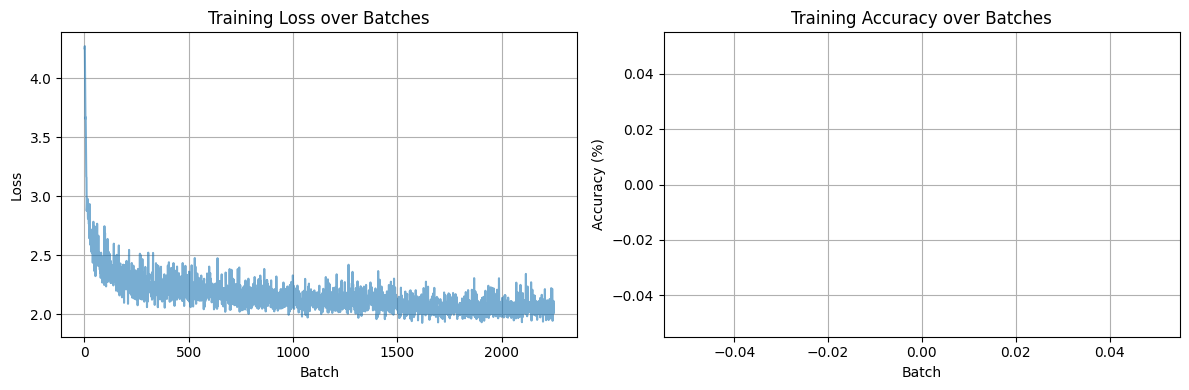

In [ ]:
# 손실 곡선 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(all_batch_losses, label='Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('CLIP Training Loss Curve')
plt.legend()
plt.savefig('clip_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

모델 추론 테스트

In [ ]:
def run_inference(model, test_dataset):
	print("\n학습 완료! 테스트 샘플로 추론을 실행합니다...")
	model.eval()

	item = test_dataset[0] # 첫 번째 테스트 이미지 사용
	image = item['image'].unsqueeze(0).to(DEVICE)
	true_label = test_dataset.class_names[test_dataset.dataset[0][1]]

	# 추론에 사용된 원본 이미지를 파일로 저장
	original_image = test_dataset.dataset[0][0]  # PIL Image
	original_image.save('clip_inference_test_image.png')
	print(f"추론에 사용된 이미지가 'clip_inference_test_image.png'로 저장되었습니다.")

	# 이미지 시각화
	import matplotlib.pyplot as plt
	plt.imshow(original_image, cmap='gray')
	plt.title(f"Test Image (True Label: {true_label})")
	plt.axis('off')
	plt.show()

	# 모든 클래스에 대한 텍스트 캡션 준비
	all_captions = [f"a photo of a {c}" for c in test_dataset.class_names]
	print(f"테스트 클래스들: {all_captions}")

	with torch.no_grad():
		# 이미지와 텍스트 임베딩 계산
		image_emb = F.normalize(model.image_projection(model.image_encoder(image)), p=2, dim=-1)

		tokenizer = test_dataset.tokenizer
		encoded_captions = tokenizer(all_captions, padding=True, truncation=True, return_tensors="pt")
		text_input = {k: v.to(DEVICE) for k, v in encoded_captions.items()}
		text_embs = F.normalize(
			model.text_projection(model.text_encoder(text_input['input_ids'], text_input['attention_mask'])),
			p=2, dim=-1
		)

	# 유사도 계산 및 예측
	similarities = (image_emb @ text_embs.T).squeeze(0)
	prediction_idx = similarities.argmax().item()

	print(f"실제 정답: '{true_label}'")
	print(f"모델 예측: '{test_dataset.class_names[prediction_idx]}'")
	print("\n--- 유사도 점수 ---")
	for i, cap in enumerate(all_captions):
		print(f"  '{cap}': {similarities[i]:.4f}")



학습 완료! 테스트 샘플로 추론을 실행합니다...
추론에 사용된 이미지가 'clip_inference_test_image.png'로 저장되었습니다.


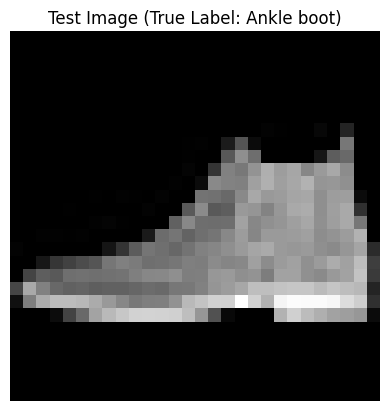

테스트 클래스들: ['a photo of a T-shirt/top', 'a photo of a Trouser', 'a photo of a Pullover', 'a photo of a Dress', 'a photo of a Coat', 'a photo of a Sandal', 'a photo of a Shirt', 'a photo of a Sneaker', 'a photo of a Bag', 'a photo of a Ankle boot']
실제 정답: 'Ankle boot'
모델 예측: 'Ankle boot'

--- 유사도 점수 ---
  'a photo of a T-shirt/top': -0.0250
  'a photo of a Trouser': -0.0303
  'a photo of a Pullover': -0.1744
  'a photo of a Dress': 0.0870
  'a photo of a Coat': -0.0668
  'a photo of a Sandal': 0.0714
  'a photo of a Shirt': -0.0179
  'a photo of a Sneaker': 0.1616
  'a photo of a Bag': -0.0242
  'a photo of a Ankle boot': 0.7986


In [61]:
# 추론 실행
test_dataset = FashionMNISTDataset(train=False, transform=get_transforms())
run_inference(model, test_dataset)

Top-k 정확도 계산

In [ ]:
def evaluate_accuracy(model, test_dataset, batch_size=32, k=5):
	model.eval()

	all_class_texts = [f"a photo of a {class_name}" for class_name in test_dataset.class_names]
	tokenizer = test_dataset.tokenizer
	encoded_texts = tokenizer(all_class_texts, padding=True, truncation=True, return_tensors="pt")
	text_input = {k: v.to(DEVICE) for k, v in encoded_texts.items()}

	with torch.no_grad(): # 모든 클래스에 대한 텍스트 임베딩 계산 (10개 클래스)
		text_embeddings = F.normalize(
			model.text_projection(model.text_encoder(text_input['input_ids'], text_input['attention_mask'])),
			p=2, dim=-1
		)  # shape: (10, PROJECTION_DIM)

	# 정확도 계산을 위한 변수
	top1_correct = 0
	topk_correct = 0
	total_samples = 0

	test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

	with torch.no_grad():
		for batch in tqdm(test_dataloader, desc="Evaluating", leave=False):
			images = batch['image'].to(DEVICE)
			labels = batch['label'].to(DEVICE)

			image_embeddings = F.normalize(
				model.image_projection(model.image_encoder(images)),
				p=2, dim=-1
			)  # shape: (batch_size, PROJECTION_DIM)

			# 이미지와 모든 텍스트 간의 유사도 계산
			similarities = image_embeddings @ text_embeddings.T

			# Top-1 예측: 가장 높은 유사도를 가진 클래스
			top1_predictions = similarities.argmax(dim=1)
			top1_correct += (top1_predictions == labels).sum().item()

			# Top-K 예측: 상위 K개 중에 정답이 있는지 확인
			topk_predictions = similarities.topk(k, dim=1).indices  # shape: (batch_size, k)
			topk_correct += (topk_predictions == labels.unsqueeze(1)).any(dim=1).sum().item()

			total_samples += labels.size(0)

	# 정확도 계산 
	top1_acc = (top1_correct / total_samples) * 100
	topk_acc = (topk_correct / total_samples) * 100
	print(f"\nTop-1 정확도: {top1_acc:.2f}%, Top-{k} 정확도: {topk_acc:.2f}%")

	return top1_acc, topk_acc

In [63]:
test_dataset = FashionMNISTDataset(train=False, transform=get_transforms())
evaluate_accuracy(model, test_dataset, batch_size=64, k=5)


Top-1 정확도: 93.37%, Top-5 정확도: 99.93%


(93.37, 99.92999999999999)